# 4. Pembangunan dan Pelatihan Model (Transfer Learning ResNet-50)
Tahapan pada notebook ini:
1. Menyiapkan Data Generator (dengan augmentasi aman untuk citra medis).
2. Membangun arsitektur Transfer Learning ResNet-50 dengan tambahan *Batch Normalization* agar komputasi stabil.
3. Melatih model menggunakan *Callbacks* (`ModelCheckpoint` & `EarlyStopping`).
4. Memvisualisasikan dan menyimpan grafik akurasi/loss (*Learning Curve*).

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import os

from sklearn.utils import class_weight
import numpy as np
from tensorflow.keras.callbacks import ReduceLROnPlateau

# 1. Menyiapkan Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=15, 
    zoom_range=0.15,
    width_shift_range=0.1, 
    height_shift_range=0.1, 
    fill_mode='nearest'
    # horizontal_flip=False (secara default sudah False, sangat aman untuk X-Ray)
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '../dataset/processed/train', 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    '../dataset/processed/val', 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical'
)

# Menampilkan Class Indices (Sangat krusial untuk evaluasi/Confusion Matrix nanti)
print("\nMapping Kelas ke Indeks Angka:")
print(train_generator.class_indices)

Found 10606 images belonging to 3 classes.
Found 2271 images belonging to 3 classes.

Mapping Kelas ke Indeks Angka:
{'COVID': 0, 'Normal': 1, 'Viral_Pneumonia': 2}


In [2]:
# 2. Memuat Model Dasar ResNet-50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Membekukan (freeze) otak dasar agar bobot pre-trained tidak rusak
for layer in base_model.layers:
    layer.trainable = False

# 3. Menambahkan Custom Head (Spesialisasi dengan Batch Normalization)
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Menormalkan sinyal dari ResNet sebelum masuk ke lapisan Dense kita
x = BatchNormalization()(x) 
x = Dense(512, activation='relu')(x)

# Menormalkan kembali sebelum masuk ke Dropout
x = BatchNormalization()(x) 
x = Dropout(0.5)(x)

# Output layer: 3 neuron karena ada 3 kelas (COVID, Normal, Viral_Pneumonia)
predictions = Dense(3, activation='softmax')(x)

# Menggabungkan otak dasar dan lapisan baru menjadi model final
model = Model(inputs=base_model.input, outputs=predictions)

print("Arsitektur Model ResNet-50 (Optimized with BatchNorm) Berhasil Dibangun!")

Arsitektur Model ResNet-50 (Optimized with BatchNorm) Berhasil Dibangun!


In [3]:
# 4. Kompilasi Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# 5. Menyiapkan Callbacks (Asisten Pelatihan)
# Menyimpan model terbaik secara otomatis ke folder 'models'
checkpoint = ModelCheckpoint(
    '../models/resnet50_best_model.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

# Menghentikan pelatihan jika selama 5 putaran tidak ada peningkatan val_loss
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

print("Model dikompilasi dan siap dilatih!")

Model dikompilasi dan siap dilatih!


In [4]:
# 6. EKSEKUSI TRAINING 

EPOCHS = 20

# 🔹 Hitung class weight (anti imbalance)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights_array))

print("\nClass Weights:", class_weights)

# 🔹 Tambahan callback biar training lebih stabil
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("\nTraining model ResNet50 sedang berjalan...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop, lr_scheduler],  # ← upgrade
    class_weight=class_weights  # ← upgrade paling penting
)

print("Training Selesai!")


Class Weights: {0: np.float64(1.3968128539444225), 1: np.float64(0.49556116250817683), 2: np.float64(3.756996103436061)}

Training model ResNet50 sedang berjalan...
Epoch 1/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4379 - loss: 1.2614
Epoch 1: val_accuracy improved from None to 0.70189, saving model to ../models/resnet50_best_model.h5



Epoch 1: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 647s 2s/step - accuracy: 0.4885 - loss: 1.0671 - val_accuracy: 0.7019 - val_loss: 0.8843 - learning_rate: 1.0000e-04
Epoch 2/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5714 - loss: 0.8478
Epoch 2: val_accuracy improved from 0.70189 to 0.74857, saving model to ../models/resnet50_best_model.h5



Epoch 2: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 613s 2s/step - accuracy: 0.5830 - loss: 0.8467 - val_accuracy: 0.7486 - val_loss: 0.5917 - learning_rate: 1.0000e-04
Epoch 3/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6088 - loss: 0.7753
Epoch 3: val_accuracy improved from 0.74857 to 0.77543, saving model to ../models/resnet50_best_model.h5



Epoch 3: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.6251 - loss: 0.7515 - val_accuracy: 0.7754 - val_loss: 0.5231 - learning_rate: 1.0000e-04
Epoch 4/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6437 - loss: 0.6979
Epoch 4: val_accuracy did not improve from 0.77543
332/332 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - accuracy: 0.6492 - loss: 0.6818 - val_accuracy: 0.7635 - val_loss: 0.5371 - learning_rate: 1.0000e-04
Epoch 5/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6629 - loss: 0.6671
Epoch 5: val_accuracy improved from 0.77543 to 0.80361, saving model to ../models/resnet50_best_model.h5



Epoch 5: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 603s 2s/step - accuracy: 0.6673 - loss: 0.6527 - val_accuracy: 0.8036 - val_loss: 0.4489 - learning_rate: 1.0000e-04
Epoch 6/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7018 - loss: 0.6125
Epoch 6: val_accuracy did not improve from 0.80361
332/332 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - accuracy: 0.7009 - loss: 0.6056 - val_accuracy: 0.7992 - val_loss: 0.4334 - learning_rate: 1.0000e-04
Epoch 7/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6902 - loss: 0.6064
Epoch 7: val_accuracy improved from 0.80361 to 0.81374, saving model to ../models/resnet50_best_model.h5


...


Epoch 10: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - accuracy: 0.7184 - loss: 0.5482 - val_accuracy: 0.8393 - val_loss: 0.3989 - learning_rate: 1.0000e-04
Epoch 11/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7293 - loss: 0.5364
Epoch 11: val_accuracy did not improve from 0.83928

Epoch 11: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
332/332 ━━━━━━━━━━━━━━━━━━━━ 523s 2s/step - accuracy: 0.7244 - loss: 0.5354 - val_accuracy: 0.8102 - val_loss: 0.4238 - learning_rate: 1.0000e-04
Epoch 12/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7244 - loss: 0.5218
Epoch 12: val_accuracy improved from 0.83928 to 0.84104, saving model to ../models/resnet50_best_model.h5



Epoch 12: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 521s 2s/step - accuracy: 0.7257 - loss: 0.5180 - val_accuracy: 0.8410 - val_loss: 0.3726 - learning_rate: 3.0000e-05
Epoch 13/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7342 - loss: 0.5007
Epoch 13: val_accuracy did not improve from 0.84104
332/332 ━━━━━━━━━━━━━━━━━━━━ 523s 2s/step - accuracy: 0.7351 - loss: 0.5088 - val_accuracy: 0.8309 - val_loss: 0.3961 - learning_rate: 3.0000e-05
Epoch 14/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7339 - loss: 0.4978
Epoch 14: val_accuracy improved from 0.84104 to 0.85161, saving model to ../models/resnet50_best_model.h5



Epoch 14: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step - accuracy: 0.7436 - loss: 0.4864 - val_accuracy: 0.8516 - val_loss: 0.3599 - learning_rate: 3.0000e-05
Epoch 15/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7466 - loss: 0.4764
Epoch 15: val_accuracy improved from 0.85161 to 0.85909, saving model to ../models/resnet50_best_model.h5



Epoch 15: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - accuracy: 0.7459 - loss: 0.4734 - val_accuracy: 0.8591 - val_loss: 0.3514 - learning_rate: 3.0000e-05
Epoch 16/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7442 - loss: 0.4838
Epoch 16: val_accuracy improved from 0.85909 to 0.86790, saving model to ../models/resnet50_best_model.h5



Epoch 16: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 540s 2s/step - accuracy: 0.7475 - loss: 0.4867 - val_accuracy: 0.8679 - val_loss: 0.3382 - learning_rate: 3.0000e-05
Epoch 17/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7495 - loss: 0.4825
Epoch 17: val_accuracy did not improve from 0.86790
332/332 ━━━━━━━━━━━━━━━━━━━━ 537s 2s/step - accuracy: 0.7490 - loss: 0.4796 - val_accuracy: 0.8565 - val_loss: 0.3577 - learning_rate: 3.0000e-05
Epoch 18/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7463 - loss: 0.4856
Epoch 18: val_accuracy did not improve from 0.86790
332/332 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.7492 - loss: 0.4757 - val_accuracy: 0.8631 - val_loss: 0.3402 - learning_rate: 3.0000e-05
Epoch 19/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7485 - loss: 0.4718
Epoch 19: val_accuracy did not improve from 0.86790

Epoch 19: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
3

Grafik berhasil disimpan ke folder 'results/training_accuracy_loss.png'


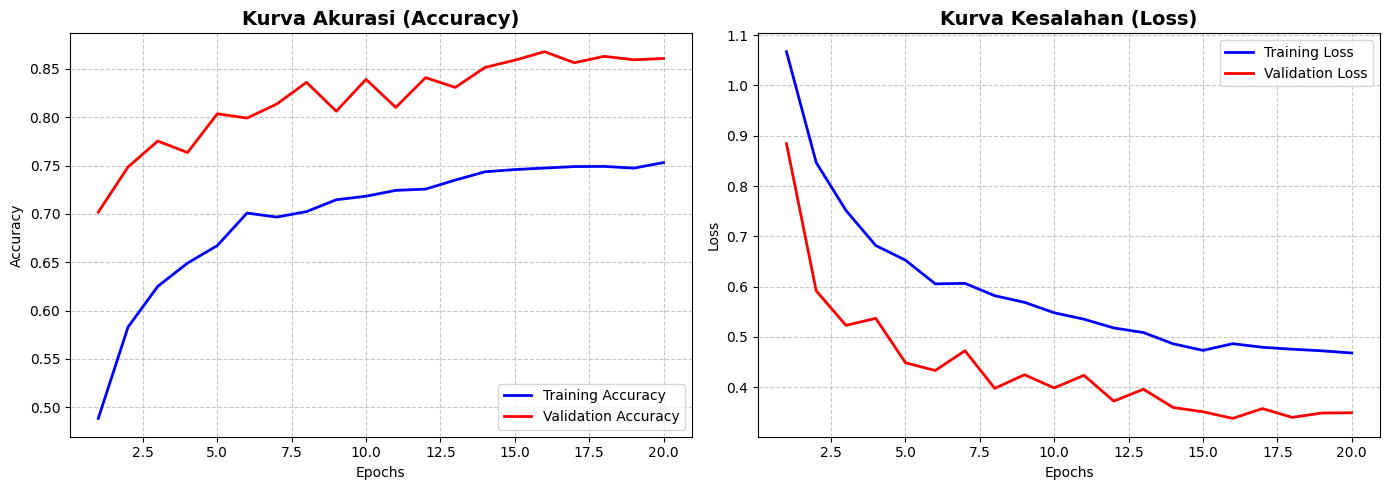

In [5]:
# 7. Memvisualisasikan dan Menyimpan Grafik Akurasi & Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Kurva Akurasi (Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.7)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2)
plt.title('Kurva Kesalahan (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(linestyle='--', alpha=0.7)

plt.tight_layout()

# Menyimpan grafik ke folder results
plt.savefig('../results/training_accuracy_loss.png', dpi=300)
print("Grafik berhasil disimpan ke folder 'results/training_accuracy_loss.png'")
plt.show()